<h1 align="center"><b>Homework Assignment 3 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 6</b></h3>
<h3 align="center"><b>Due at the end of Module 8</b></h3><br>

# Q1 — Solving Einstein’s Riddle as a CSP

## 35 points total

**Einstein’s Riddle:**

There are **5 houses in a row**, each with a different color. Each house has an owner of a different nationality, a pet, a drink, and a cigar brand. The following clues apply:

1. The Brit lives in the red house.  
2. The Swede keeps dogs as pets.  
3. The Dane drinks tea.  
4. The green house is immediately to the left of the white house.  
5. The green house’s owner drinks coffee.  
6. The person who smokes Pall Mall rears birds.  
7. The owner of the yellow house smokes Dunhill.  
8. The man living in the center house drinks milk.  
9. The Norwegian lives in the first house.  
10. The man who smokes Blends lives next to the one who keeps cats.  
11. The man who keeps horses lives next to the man who smokes Dunhill.  
12. The man who smokes Blue Master drinks beer.  
13. The German smokes Prince.  
14. The Norwegian lives next to the blue house.  
15. The man who smokes Blends has a neighbor who drinks water.  

**Question**: Who owns the fish?

---

### [15 points] Part A – Coding (Implementation)

1. Model Einstein’s Riddle as a CSP using **OR-Tools CP-SAT**.  
   - **Variables**: House positions (1–5) for each attribute (color, nationality, pet, drink, cigar).  
   - **Domains**: {1, 2, 3, 4, 5}.  
   - **Constraints**: Encode the 15 given rules.  

2. Use the solver to find the unique solution.  

3. Print the assignments in a human-readable table.

---

### [20 points] Part B – Analysis (Explanation)

1. **Constraint Graph**:  
   Draw the constraint graph where nodes = attributes, edges = binary constraints (e.g., “Swede → Dogs”).  
   Classify each clue as **unary**, **binary**, or **positional**.

2. **Search Space Size**:  
   - Without constraints: how many permutations of 5 attributes across 5 houses?  
   - After adding AllDifferent + clue constraints: how much is pruned?  

3. **Constraint Propagation**:  
   Explain how AC-3 or forward checking would prune the domains before any search is done.  

4. **Complexity**:  
   Compare **pure backtracking** vs. **backtracking + constraint propagation** in terms of Big-O and expected runtime.  

5. **Reflection**:  
   Why does this puzzle have a *unique* solution, even though the search space is enormous?  
   How does that illustrate the power of CSP methods?


In [11]:
##  Coding Solution

import subprocess
import sys

try:
    from ortools.sat.python import cp_model
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ortools"])
    from ortools.sat.python import cp_model
# Needed for the solution, set up script so it installs if not present. so make venv if needed and install.

model = cp_model.CpModel()

# House numbers 1-5
houses = range(1, 6)

# Create variables for each attribute value
# Each variable = which house number that attribute lives in
#model.NewIntVar(min, max, 'name')
# Variable specific constraints model.Add(norwegian == 1)
# General Constraints model.AddAllDifferent(...)
# Relational Constraint model.Add(brit == red)
#  model.NewIntVar(1, 5, 'red') -> argument 1 is the min value of the domain, argument 2 is the max value of domain, 3rd is j name for debugging or printing later
colors = {
    'red':    model.NewIntVar(1, 5, 'red'),
    'green':  model.NewIntVar(1, 5, 'green'),
    'white':  model.NewIntVar(1, 5, 'white'),
    'yellow': model.NewIntVar(1, 5, 'yellow'),
    'blue':   model.NewIntVar(1, 5, 'blue'),
}

nationalities = {
    'brit':     model.NewIntVar(1, 5, 'brit'),
    'swede':    model.NewIntVar(1, 5, 'swede'),
    'dane':     model.NewIntVar(1, 5, 'dane'),
    'norwegian':model.NewIntVar(1, 5, 'norwegian'),
    'german':   model.NewIntVar(1, 5, 'german'),
}

pets = {
    'dogs':   model.NewIntVar(1, 5, 'dogs'),
    'birds':  model.NewIntVar(1, 5, 'birds'),
    'cats':   model.NewIntVar(1, 5, 'cats'),
    'horses': model.NewIntVar(1, 5, 'horses'),
    'fish':   model.NewIntVar(1, 5, 'fish'),
}

drinks = {
    'tea':    model.NewIntVar(1, 5, 'tea'),
    'coffee': model.NewIntVar(1, 5, 'coffee'),
    'milk':   model.NewIntVar(1, 5, 'milk'),
    'beer':   model.NewIntVar(1, 5, 'beer'),
    'water':  model.NewIntVar(1, 5, 'water'),
}

cigars = {
    'pallmall':   model.NewIntVar(1, 5, 'pallmall'),
    'blends':     model.NewIntVar(1, 5, 'blends'),
    'dunhill':    model.NewIntVar(1, 5, 'dunhill'),
    'bluemaster': model.NewIntVar(1, 5, 'bluemaster'),
    'prince':     model.NewIntVar(1, 5, 'prince'),
}


# Adding General Constraints (ensuring the different variables are different for the different houses)
# In each group, every variable must have a different house number
model.AddAllDifferent(colors.values())
model.AddAllDifferent(nationalities.values())
model.AddAllDifferent(pets.values())
model.AddAllDifferent(drinks.values())
model.AddAllDifferent(cigars.values())

# Variabel Constraints
#The Brit lives in the red house
model.Add(nationalities['brit'] == colors['red'])

# The Swede keeps dogs
model.Add(nationalities['swede'] == pets['dogs'])

# The Dane drinks tea
model.Add(nationalities['dane'] == drinks['tea'])

# Green house is immediately to the left of white house
model.Add(colors['green'] + 1 == colors['white'])

# Green house owner drinks coffee
model.Add(colors['green'] == drinks['coffee'])

# Pall Mall smoker rears birds
model.Add(cigars['pallmall'] == pets['birds'])

# Yellow house owner smokes Dunhill
model.Add(colors['yellow'] == cigars['dunhill'])

# Center house owner drinks milk
model.Add(drinks['milk'] == 3)

# Norwegian lives in first house
model.Add(nationalities['norwegian'] == 1)

# Blends smoker lives next to cat owner
# To handle both differences, one would lead to 1 and the other subtraction -1. This way we can have like adouble check 
model.Add(cigars['blends'] - pets['cats'] <= 1)
model.Add(pets['cats'] - cigars['blends'] <= 1)

# Horse owner lives next to Dunhill smoker
model.Add(pets['horses'] - cigars['dunhill'] <= 1)
model.Add(cigars['dunhill'] - pets['horses'] <= 1)

# Blue Master smoker drinks beer
model.Add(cigars['bluemaster'] == drinks['beer'])

# German smokes Prince
model.Add(nationalities['german'] == cigars['prince'])

# Norwegian lives next to blue house
model.Add(nationalities['norwegian'] - colors['blue'] <= 1)
model.Add(colors['blue'] - nationalities['norwegian'] <= 1)

# Blends smoker has a neighbor who drinks water
model.Add(cigars['blends'] - drinks['water'] <= 1)
model.Add(drinks['water'] - cigars['blends'] <= 1)

# Initializing the solver and then having it assign values in our CSP problem
solver = cp_model.CpSolver()
status = solver.Solve(model)

# printing the solutions for each variable from each dict
if status == cp_model.FEASIBLE or status == cp_model.OPTIMAL:
    
    # Build a table indexed by house number
    table = {i: {} for i in range(1, 6)}
    
    for name, var in colors.items():
        table[solver.Value(var)]['color'] = name
    for name, var in nationalities.items():
        table[solver.Value(var)]['nationality'] = name
    for name, var in pets.items():
        table[solver.Value(var)]['pet'] = name
    for name, var in drinks.items():
        table[solver.Value(var)]['drink'] = name
    for name, var in cigars.items():
        table[solver.Value(var)]['cigar'] = name

    # Padding and formatting table
    print(f"{'House':<8} {'Color':<10} {'Nationality':<14} {'Pet':<10} {'Drink':<10} {'Cigar':<12}")
    print("-" * 65)
    for house in range(1, 6):
        row = table[house]
        print(f"{house:<8} {row['color']:<10} {row['nationality']:<14} {row['pet']:<10} {row['drink']:<10} {row['cigar']:<12}")

    # Answer the question
    for name, var in pets.items():
        if name == 'fish':
            owner_house = solver.Value(var)
    for name, var in nationalities.items():
        if solver.Value(var) == owner_house:
            print(f"\nThe {name} owns the fish")
else:
    print("No solution found")

House    Color      Nationality    Pet        Drink      Cigar       
-----------------------------------------------------------------
1        blue       norwegian      horses     beer       bluemaster  
2        yellow     swede          dogs       water      dunhill     
3        red        brit           cats       milk       blends      
4        green      german         fish       coffee     prince      
5        white      dane           birds      tea        pallmall    

The german owns the fish


### Your response goes here

## My answer to B

I used mermaid js to make my graph and attaching it as a png to my submission

## Constraint Classification

Made a table via the md

| Clue | Constraint | Type |
|------|------------|------|
| 1 | Brit = Red house | Binary |
| 2 | Swede = Dogs | Binary |
| 3 | Dane = Tea | Binary |
| 4 | Green immediately left of White | Positional |
| 5 | Green = Coffee | Binary |
| 6 | Pall Mall = Birds | Binary |
| 7 | Yellow = Dunhill | Binary |
| 8 | Milk = House 3 | Unary |
| 9 | Norwegian = House 1 | Unary |
| 10 | Blends next to Cats | Positional |
| 11 | Horses next to Dunhill | Positional |
| 12 | Blue Master = Beer | Binary |
| 13 | German = Prince | Binary |
| 14 | Norwegian next to Blue | Positional |
| 15 | Blends next to Water | Positional |

**So there are 2 unary constraints, 8 binary constraints, 5 positional constraints**


## Search Space Size

Without constraints there would be 5! permutations per group. So there are 5 groups and in each group there are 5 values being assigned to 5 houses making 120 combinations in a singular group. So since there are 5 groups and a single group could have 120 combinations it would result in 120^5 permutations.

After adding the general constriant and the variable constraints the space is pruned by a large amount. The different variable constraints and the general, alldifferent constraint prune the total permutations from 120^5 to just 1 valid option which the solver finds quickly by pruning invalid branches early on.

## Constraint Propagation

Both of these methods prune the domains before and during the search in order to reduce search space. Forward checking would prune domains for linked variables when an assignment is made. So for example if norwegian is in house 1 and we know blue is next to norwegian it then prunes blue's domain since it is linked to the norwegian variable via a variable constraint. AC-3 on the other hand would be more proactive. It would do the same process plus look at what other variable blue is linked to and prune the other linked variables accordingly and it happens before and during the actual search. It keeps on checking all of the connected variables again and again constantly updating variable domains throughout the process where as forward checking only occurs per assignment, to directly connected variables.

## Complexity

If we were not to have any constraint propagation the big O would be O(d^n) where d is the domain size (5) and n is the number of variables (total variables, 5 categories * 5 possibilities = 25) making it 5^25 which is a huge exponetial runtime.

With backtracking and constraint propagation we prune very large chunks of the tree before even exploring them. In this problem we reduce the search by a very large time but the runtime is still O(d^n) but the difference is that it is so much faster because we prune many of the branches early.

The difference is not the big O (worst case scenario), but rather the runtime. The constraint propagation turns a problem that we would take ages trying to get a combination of assigned values to something that can be solved in seconds.

## Reflection

The puzzle has a unique solution because we can utalize the general and variable constraints to prune many of the tree branches very early on before traversing given a state.The 15 variable constraints are made so that the remove all of the possible combinations except for 1 true solution. Each constraint removes part of the search space and they are precise enough such that they lead to one possible solution. If even one of the constraint was removed there could be multiple valid solution.

It illustrates the power of CSP methods by dramatically reducing runtime by preventing traversal of possible branches that could not be possible given a change in state of the graph. Even though the raw search is 120^5 combinations the constraints reduce it down to 1 valid solution. CSP methods like backtracking and constriant propagation prune branches early, preventing the traversal of large parts of the tree that could never lead to a valid solution. If we used brute force it would take ages where as we can do this in seconds because the constraints (and pruning) do majority of the work in finding the solution.

# Q2 — Principal Component Analysis on MNIST  

## 35 points total

In this problem, you will implement **Principal Component Analysis (PCA)** from scratch using the MNIST dataset. You must not use the built-in PCA functions in scikit-learn. Instead, you will write the steps yourself using NumPy. Use at least **1000 samples** and ensure the data is class-balanced.  

You may download the dataset from either of the following sources:  
- Import directly into your notebook
- Alternative dataset links: [GTDLBench](https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/), [Kaggle](https://www.kaggle.com/datasets/hojjatk/mnist-dataset), [Hugging Face](https://huggingface.co/datasets/ylecun/mnist)

---

## [15 points] Part A – Coding (Implementation)  

### Data Preparation  
- Load MNIST 
- Select at least **1000 balanced samples**.  
- Flatten images into vectors and **standardize the data**.  

### PCA from Scratch  
- Compute the **covariance matrix**.  
- Find **eigenvalues** and **eigenvectors**.  
- Sort eigenvalues and project the data into the new space.  

### Variance Explained  
- Plot the **explained variance** (scree plot).  
- Determine how many principal components to retain.  

---

## [20 points] Part B – Analysis (Explanation)  

### Component Selection  
- Justify your choice of how many components to keep.  
- Discuss trade-offs between dimensionality reduction and information retention.  

### Visualization  
- Create at least **five distinct 2D scatter plots** of the data projected onto different pairs of principal components (e.g., PC1 vs. PC2, PC2 vs. PC3, etc.), coloring points by digit class.  
- Comment on what these plots reveal about **class separability** and **structure** in the data.  

### Interpretation  
- Explain why each step of PCA matters (**covariance, eigenvalues, variance explained**).  
- Discuss one **real-world application** where PCA would be useful.  


Dataset shape: (1000, 784)
Labels: [0 1 2 3 4 5 6 7 8 9]
Covariance matrix shape: (784, 784)
Top 5 eigenvalues: [325397.5 249858.5 232605.2 182618.  163961. ]
80% variance -> 40 components
90% variance -> 77 components
95% variance -> 130 components


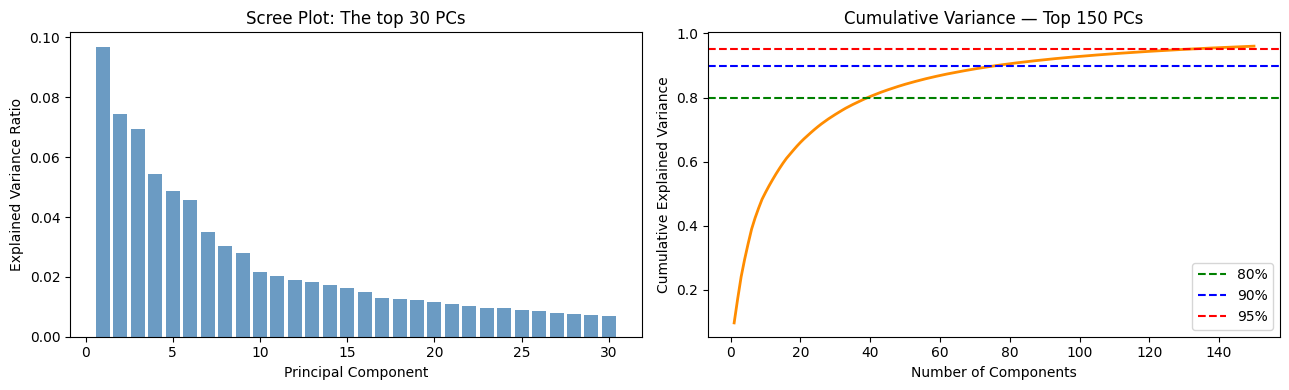

Original shape: (1000, 784)
Projected shape: (1000, 40)


C:\Users\Devan\AppData\Local\Temp\ipykernel_28028\3848634561.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = plt.cm.get_cmap('tab10', 10)  # one color per digit


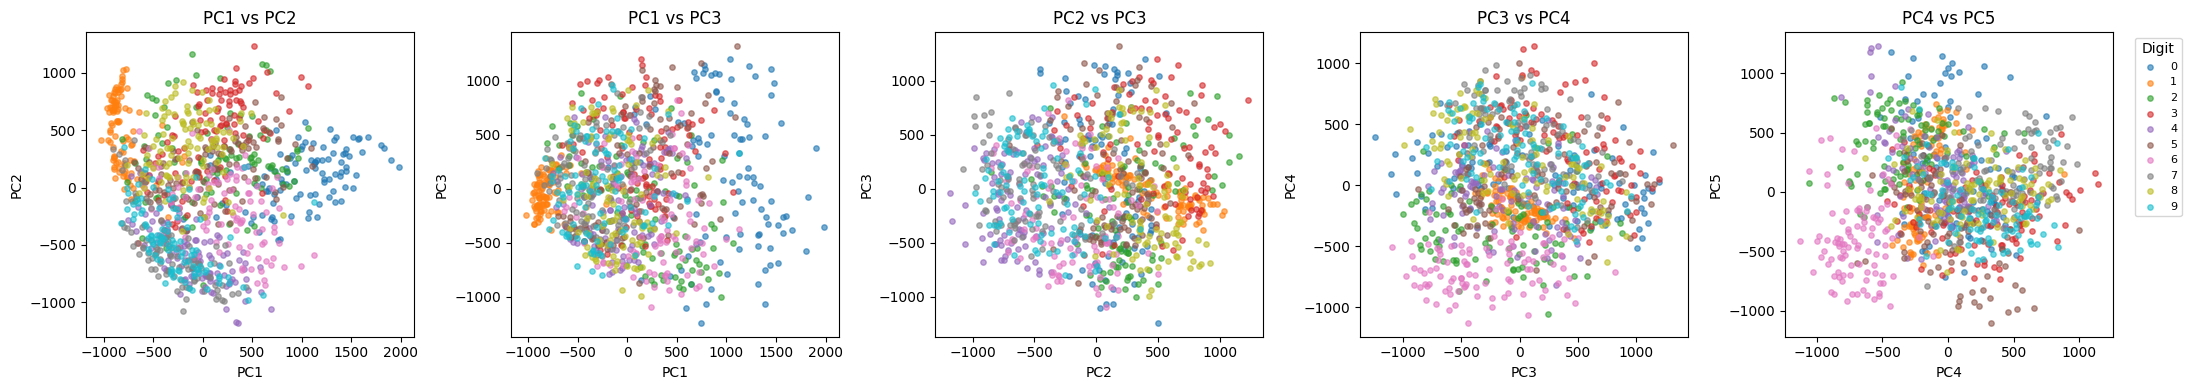

In [23]:
## Your code goes here
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import numpy as np
except ImportError:
    install('numpy')
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:
    install('matplotlib')
    import matplotlib.pyplot as plt

try:
    from sklearn.datasets import fetch_openml
except ImportError:
    install('scikit-learn')
    from sklearn.datasets import fetch_openml

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Loading MNIST
# returns batch object
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# assiging batch object sections to vars data-> labels, features -> target
X, y = mnist.data, mnist.target.astype(int)

# getting balanced samples
samples_per_class = 100
indices = []
for digit in range(10):
    #first 100 indices where condition is true for each digit
    digit_indices = np.where(y == digit)[0][:samples_per_class]

    #row num get put into list for each digit
    indices.extend(digit_indices)

#getting the feature and label rows for the values in indices index
X_balanced = X[indices]
y_balanced = y[indices]

print(f"Dataset shape: {X_balanced.shape}")  # should be (1000, 784)
print(f"Labels: {np.unique(y_balanced)}")    # should be 0-9

# Mean center the data, means how difference is brightness from avg
X_mean     = np.mean(X_balanced, axis=0)   # average value of each pixel across all 1000 images
X_centered = X_balanced - X_mean           # shape (1000, 784) every image shifted by the mean


# Covariance matrix
n = X_centered.shape[0]                     # 1000 — number of samples
cov_matrix = (X_centered.T @ X_centered) / (n - 1)  # shape (784, 784), n-1 for true covariance
#transpose and matrix multiplication

print(f"Covariance matrix shape: {cov_matrix.shape}")

# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh returns eigenvalues in ascending order 
eigenvalues  = eigenvalues[::-1].copy()
eigenvectors = eigenvectors[:, ::-1].copy()

print(f"Top 5 eigenvalues: {eigenvalues[:5].round(1)}")


# Explained variance
total_var           = np.sum(eigenvalues)
explained_var_ratio = eigenvalues / total_var      # each PCs share as fraction (0 to 1)
cumulative_var      = np.cumsum(explained_var_ratio) # total

# number of PCs that we hit common thresholds
for threshold in [0.80, 0.90, 0.95]:
    k = int(np.argmax(cumulative_var >= threshold)) + 1
    print(f"{threshold*100:.0f}% variance -> {k} components")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left is individual variance per PC
axes[0].bar(range(1, 31), explained_var_ratio[:30], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot: The top 30 PCs')

# Right is cumulative variance
axes[1].plot(range(1, 151), cumulative_var[:150], color='darkorange', linewidth=2)
axes[1].axhline(0.80, color='green',  linestyle='--', label='80%')
axes[1].axhline(0.90, color='blue',   linestyle='--', label='90%')
axes[1].axhline(0.95, color='red',    linestyle='--', label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance — Top 150 PCs')
axes[1].legend()

plt.tight_layout()
plt.show()

# Projecting data onto top 40 PCs
n_keep = 40
W = eigenvectors[:, :n_keep] # grab the top 40 eigenvectors -> shape (784, 40)
X_pca  = X_centered @ W # project -> shape (1000, 40)

print(f"Original shape: {X_balanced.shape}")
print(f"Projected shape: {X_pca.shape}")

# 5 scatter plots of different PC pairs
colors_map = plt.cm.get_cmap('tab10', 10)  # one color per digit

pc_pairs = [(0,1), (0,2), (1,2), (2,3), (3,4)]  # 5 different pairs (0-indexed)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (pc_a, pc_b) in zip(axes, pc_pairs):
    for digit in range(10):
        mask = y_balanced == digit # boolean mask for digit
        ax.scatter(X_pca[mask, pc_a], # x-axis: PC pc_a scores
                   X_pca[mask, pc_b], # y-axis: PC pc_b scores
                   label=str(digit),
                   color=colors_map(digit),
                   alpha=0.6, s=15)
    ax.set_xlabel(f'PC{pc_a + 1}')
    ax.set_ylabel(f'PC{pc_b + 1}')
    ax.set_title(f'PC{pc_a+1} vs PC{pc_b+1}')

axes[-1].legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# The features we were using were already standardized so we did not need to scale them via a scaling class method


## Your analysis goes here

## Component Selection

I chose 40 components which capture about 80% of the total variance in the dataset. The scree plot shows a drop off after the first few components then flattens indicating that early PCs have the most meaningful information while the later ones mostly capture noise

There is a trade off between dimensionality reduction and information retention. Keeping the 40 components that I did, it reduces the feature space from 784 dimensions down to 40 which is a large reduction but it also keeps 80% of the variance. Increasing the kept components  retains more information but it also decreases the benefit the dimensionality reduction.


## Visualization

**PC1 vs PC2:** This shows the clearest seperation between the digit classes. There are some digits that form loose clusters in regions that are in far out locations of the plot and that tells us the directions of maximum variance do capture the meaningful differences between digit shapes


**PC1 vs PC3 and PC2 vs PC3:** These show modeerate structures with some clusters visible but there are more overlap between classes


**PC3 vs PC4 and PC4 vs PC5:** These show progressively more overlap, with the digits bunching up towards the center, but this is what we should expect because later PCs capture less and less variance and because of that they carry less class discriminative info

Overall the plots do confirm that PCA captures real structural data but since PCA is unsupervised it does not optimize for class seperation. It only finds the directions of the max variance. Some of the variance reflects in the digit shape differences, but some can be based due to handwriting style, thickness of the strokes make by the writer and other factors.


## Interpretation

**covariance**: Covariance captures how pairs of features can vary accross all of our samples. It basically shows us the relationships betweent he pixels (in this case) and what is what PCA needs to find the direction of the max spread in the data

**eigenvalues:** Eigenvalues measure how much variance exists along each direction. Larger eigenvaleus mean the direction has more meaningful structure in the data and is worth keeping

**Variance:** Variance tells us what fraction of the total information each component makes up. It lets us make an informed decision about how many components to keep based on how much fo teh data's sstructure we want to keep instact.


A real world application of PCA is face recognition. Raw face images are high dimensional but most variance comes from the small features in different induviduals from their facial features. PCA compresses each face into a low dimensional vector making the facial recognition faster and less sensitive to noise and avoids possibility of overfitting.

# Q3 — Training Models with Gradient Descent and Its Variants  

## 30 points total

In this problem, you will get hands-on experience with gradient-based optimization algorithms. You will first apply them to a simple convex model (logistic regression) and then explore their behavior on a small non-convex model (neural network). The goal is to understand how and why these algorithms behave differently in practice.

---

## [10 points] Part A – Learning to separate two classes  

In this part, you will implement gradient descent from scratch to understand how it learns and converges.

### Dataset  

```python
import numpy as np

# Simple linearly separable data
X = np.array([[0,1],[1,2],[2,1],[3,2],[3,4],[4,3],[5,4],[6,5]])
y = np.array([0,0,0,0,1,1,1,1])  # 0 = Class A, 1 = Class B

```

### Model
- Implement logistic regression using batch gradient descent (use all data to compute the gradient each step).
- Start all parameters $(w, b)$ = 0, learning rate = 0.1.
- Run 1000 updates and plot the loss curve (loss vs. iterations).

### Visualization and Interpretation
- Draw a scatter plot showing the decision boundary learned by your model.
- Provide interpretation of your plot(s), such as
    - Does the loss steadily decrease? 
    - How does learning rate affect stability?


## [10 points] Part B – Comparing how fast models learn  

In this part, you will use gradient descent as a baseline and compare it to other optimizers.

### Dataset and Model

- Use the same dataset and loss function as in Part A.
- Train the same model using three optimizers
    - Batch Gradient Descent (GD)
    - Stochastic Gradient Descent (SGD)
    - Adam 
- Run each for 20 epochs.

### Visualization and Interpreation
- Plot all three loss curves on one graph.
- Provide interpretation of your plot(s), such as convergence speed, stability, etc.


## [10 points] Part C - Non-Convex Terrain

In this part, you will explore how optimization behaves in non-convex landscapes, where initialization matters.

### Model

- Build and train a tiny neural network, with its architecture as \
Input -> Hidden Layer (2 neurons, ReLU) -> Output (Sigmoid)
- Train the nework using Adam on the same dataset as in Part A.
- Run the training three times with different random weight initializations.


### Visualization and Interpreation
- Plot the loss curve for each run
- Discuss your results and plots, for example, 
    - Do all runs end at the same loss value?
    - Why might some runs get "stuck" higher?
    - What does this show about challenges of non-convex optimization?








 


Final weights: w = [0.53872605 1.6591005 ], b = -5.7339
Final loss:    0.113519


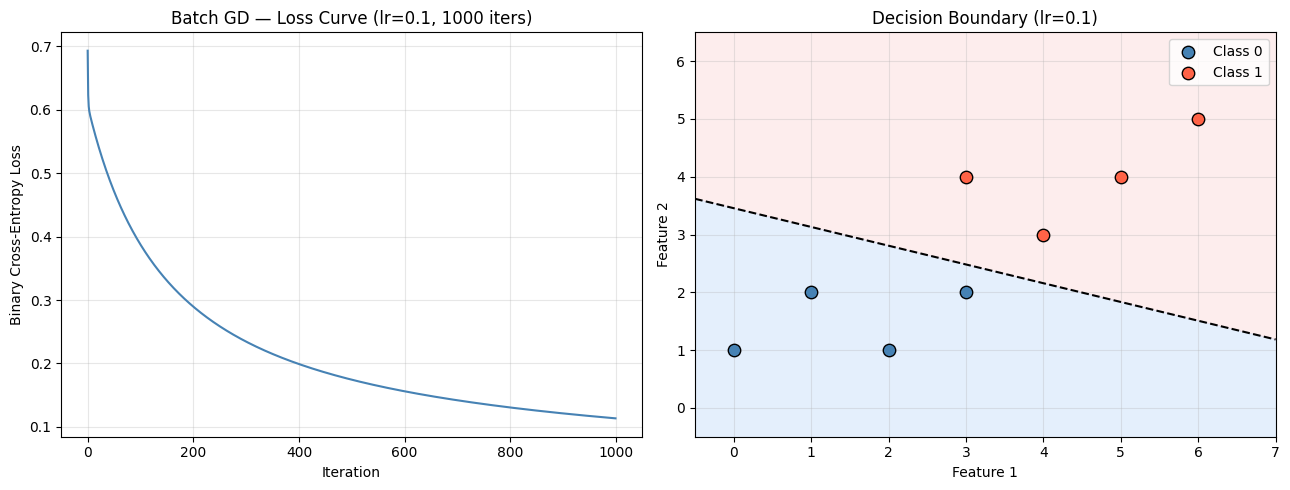

In [ ]:
## Your code goes here

#Part 3a Logistic Regression from Scratch (Batch GD)

import numpy as np
import matplotlib.pyplot as plt

# Dataset 
X = np.array([[0,1],[1,2],[2,1],[3,2],[3,4],[4,3],[5,4],[6,5]], dtype=float)
y = np.array([0,0,0,0,1,1,1,1], dtype=float)
m = len(y)

# Sigmoid to scale for logistic regression (0,1) 
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary Cross-Entropy Loss
def bce_loss(y_true, y_hat):
    # clip to avoid log(0)
    eps = 1e-9
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_hat) + (1 - y_true) * np.log(1 - y_hat))

# Batch Gradient Descent
def train_logistic_batch_gd(X, y, lr=0.1, n_iter=1000):
    n_features = X.shape[1]
    w = np.zeros(n_features) # shape (2,)
    b = 0.0
    losses = []

    for i in range(n_iter):
        # Forward pass
        z = X @ w + b
        y_hat = sigmoid(z) 

        # Loss
        loss = bce_loss(y, y_hat)
        losses.append(loss)

        # Gradients (the clean BCE+sigmoid result)
        error = y_hat - y
        dw = (X.T @ error) / m
        db = np.mean(error) # scalar

        # Gradient
        w -= lr * dw
        b -= lr * db

    return w, b, losses

# Training
w, b, losses = train_logistic_batch_gd(X, y, lr=0.1, n_iter=1000)

print(f"Final weights: w = {w}, b = {b:.4f}")
print(f"Final loss:    {losses[-1]:.6f}")

# Plot Loss Curve 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(losses, color='steelblue', linewidth=1.5)
axes[0].set_title("Batch GD — Loss Curve (lr=0.1, 1000 iters)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

# Decision Boundary
# The boundary is where sigmoid(w·x + b) = 0.5, i.e. w·x + b = 0
# → x2 = -(w[0]*x1 + b) / w[1]

x1_range = np.linspace(-0.5, 7, 200)
x2_boundary = -(w[0] * x1_range + b) / w[1]

# Background shading w/ meshgrid
xx1, xx2 = np.meshgrid(np.linspace(-0.5, 7, 300), np.linspace(-0.5, 6.5, 300))
Z = sigmoid(np.c_[xx1.ravel(), xx2.ravel()] @ w + b).reshape(xx1.shape)

axes[1].contourf(xx1, xx2, Z, levels=[0, 0.5, 1], alpha=0.15,
                 colors=['#4e9af1', '#f28c8c'])
axes[1].contour(xx1, xx2, Z, levels=[0.5], colors='black',
                linewidths=1.5, linestyles='--')

mask0 = y == 0
mask1 = y == 1
axes[1].scatter(X[mask0, 0], X[mask0, 1], c='steelblue', edgecolors='k',
                s=80, label='Class 0', zorder=5)
axes[1].scatter(X[mask1, 0], X[mask1, 1], c='tomato', edgecolors='k',
                s=80, label='Class 1', zorder=5)

axes[1].set_title("Decision Boundary (lr=0.1)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("q3a_plots.png", dpi=150, bbox_inches='tight')
plt.show()

## Your analysis goes here

## 3A

The loss decreases rapidly at first and then flattens. In our example it decreases exponentially from where it had started out, starting high up early on and then suddenly flatening out around 0.1. The reason it decreases like this is because logistic regression with BCE loss is convex and there is only one minimum, it has no bumps and every step will always go downwards.

The learning rate basically helps us scale how much we alter the weights to decrease the loss each itteration. When the learning rate is large our weight adjustment would be scaled way too much and can easily cause us to skip over the minimum loss and we are unable to get to exactly that point. If the learning rate is too small we may technically reach the minimum, but since we scaled it so small it would take very long.

## Section 3B

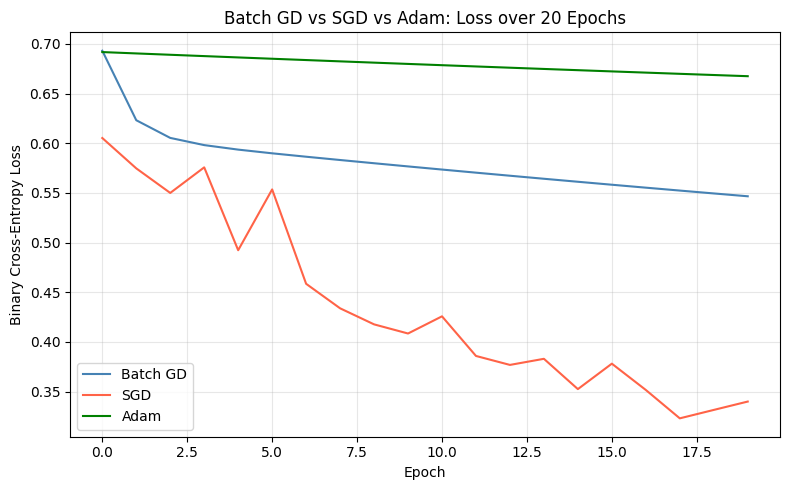

In [26]:
# 3B Comparing Batch GD vs SGD vs Adam

def train_sgd(X, y, lr=0.1, n_epochs=20):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []
    m = len(y)
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        for i in indices:
            xi = X[i]
            yi = y[i]
            z = np.dot(xi, w) + b
            y_hat = sigmoid(z)
            error = y_hat - yi
            w -= lr * error * xi
            b -= lr * error
        y_hat_all = sigmoid(X @ w + b)
        losses.append(bce_loss(y, y_hat_all))
    return w, b, losses

def train_adam(X, y, lr=0.001, n_epochs=20, b1=0.9, b2=0.999, eps=1e-8):
    w = np.zeros(X.shape[1])
    b = 0.0
    mw = np.zeros_like(w)
    vw = np.zeros_like(w)
    mb = 0.0
    vb = 0.0
    losses = []
    m = len(y)
    t = 0
    for epoch in range(n_epochs):
        t += 1
        z = X @ w + b
        y_hat = sigmoid(z)
        error = y_hat - y
        dw = (X.T @ error) / m
        db = np.mean(error)
        mw = b1*mw + (1-b1)*dw
        vw = b2*vw + (1-b2)*(dw**2)
        mb = b1*mb + (1-b1)*db
        vb = b2*vb + (1-b2)*(db**2)
        mw_hat = mw / (1 - b1**t)
        vw_hat = vw / (1 - b2**t)
        mb_hat = mb / (1 - b1**t)
        vb_hat = vb / (1 - b2**t)
        w -= lr * mw_hat / (np.sqrt(vw_hat) + eps)
        b -= lr * mb_hat / (np.sqrt(vb_hat) + eps)
        losses.append(bce_loss(y, sigmoid(X @ w + b)))
    return w, b, losses

# Train all three
np.random.seed(42)
n_epochs = 20
_, _, losses_batch = train_logistic_batch_gd(X, y, lr=0.1, n_iter=n_epochs)
_, _, losses_sgd   = train_sgd(X, y, lr=0.1, n_epochs=n_epochs)
_, _, losses_adam  = train_adam(X, y, lr=0.001, n_epochs=n_epochs)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(losses_batch, label='Batch GD',  color='steelblue')
plt.plot(losses_sgd,   label='SGD', color='tomato')
plt.plot(losses_adam,  label='Adam', color='green')
plt.title("Batch GD vs SGD vs Adam: Loss over 20 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3b_plots.png", dpi=150, bbox_inches='tight')
plt.show()

## 3B Questions

Across the 20 epochs, the three optimizers behave very differently. Batch GD decreases steadily since it uses all 8 of the points to compute a clean gradient pear epoch, but it converges slowl at 0.55 after 20 epochs. SGD drops the fastest and reaches the lowest loss by epoch 20, however its path is noisy and jagged because each update uses only one point and at random too which means that induvidual updates can temporarily make things worse before improving later on. Adam barely moves in this because it has a learning rate of 0.001 which is very small and 20 epochs is not nearly enough for a learning rate at that size. Adam is designed for much larger problems so that it self adjusts its step sizes over the many many itterations and grows to outperform the other methods, but on this dataset it is too small and too few epochs causing it to look like its stalling.

## Section 3C

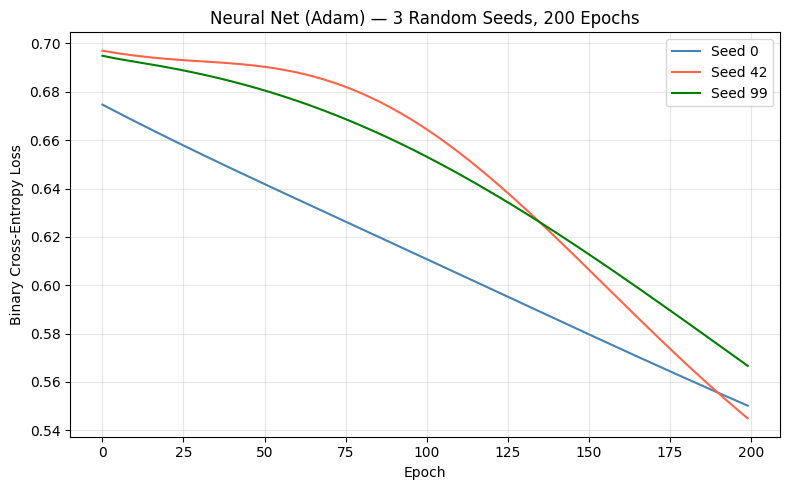

In [27]:
# 3C Tiny Neural Network with Adam, 3 random seeds

def train_neural_net(X, y, seed, lr=0.001, n_epochs=200):
    np.random.seed(seed)
    
    # Initializing weights randomly
    W1 = np.random.randn(2, 2) * 0.1  # input(2) → hidden(2)
    b1 = np.zeros(2)
    W2 = np.random.randn(2, 1) * 0.1  # hidden(2) → output(1)
    b2 = np.zeros(1)
    
    # Adam params
    mW1,vW1 = np.zeros_like(W1),np.zeros_like(W1)
    mb1,vb1 = np.zeros_like(b1),np.zeros_like(b1)
    mW2,vW2 = np.zeros_like(W2),np.zeros_like(W2)
    mb2,vb2 = np.zeros_like(b2),np.zeros_like(b2)
    b1_adam, b2_adam, eps = 0.9, 0.999, 1e-8
    
    losses = []
    m = len(y)
    
    for t in range(1, n_epochs+1):
        # Forward pass
        Z1 = X @ W1 + b1 # (8,2)
        A1 = np.maximum(0, Z1) # ReLU
        Z2 = A1 @ W2 + b2 # (8,1)
        A2 = sigmoid(Z2.ravel()) # output probability
        
        loss = bce_loss(y, A2)
        losses.append(loss)
        
        # Backward pass
        dA2 = A2 - y # (8,)
        dZ2 = dA2.reshape(-1,1) # (8,1)
        dW2 = A1.T @ dZ2 / m # (2,1)
        db2 = np.mean(dZ2, axis=0) # (1,)
        dA1 = dZ2 @ W2.T # (8,2)
        dZ1 = dA1 * (Z1 > 0) # ReLU derivative
        dW1 = X.T @ dZ1 / m # (2,2)
        db1_grad = np.mean(dZ1, axis=0) # (2,)
        
        # Adam updates for each parameter
        def adam_update(param, grad, m_, v_, t):
            m_ = b1_adam*m_ + (1-b1_adam)*grad
            v_ = b2_adam*v_ + (1-b2_adam)*(grad**2)
            m_hat = m_ / (1 - b1_adam**t)
            v_hat = v_ / (1 - b2_adam**t)
            param -= lr * m_hat / (np.sqrt(v_hat) + eps)
            return param, m_, v_

        W2, mW2, vW2 = adam_update(W2, dW2, mW2, vW2, t)
        b2, mb2, vb2 = adam_update(b2, db2, mb2, vb2, t)
        W1, mW1, vW1 = adam_update(W1, dW1, mW1, vW1, t)
        b1, mb1, vb1 = adam_update(b1, db1_grad, mb1, vb1, t)
    
    return losses

# Train 3 times with different seeds
seeds = [0, 42, 99]
colors = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8,5))
for seed, color in zip(seeds, colors):
    losses = train_neural_net(X, y, seed=seed, lr=0.001, n_epochs=200)
    plt.plot(losses, label=f'Seed {seed}', color=color)

plt.title("Neural Net (Adam) — 3 Random Seeds, 200 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3c_plots.png", dpi=150, bbox_inches='tight')
plt.show()

## 3C Questions

All 3 runs show the loss decreasing but all three converge at different speeds and reach different loss values at the 200th epoch despite using the same model and optimizer. The only difference between them is the random seed,  which controls how the weights are initialized in the beginning. This shows neural networks on the have a non convex loss surface and can deal with possibly many local minima. Depending on where the weights start, the model can end up rolling downhil towards a different minima from each other. Some starting points might lead to faster convergance or a lower final loss than the otehrs. This is why neural networks are often trained wiht multiple different initializations and the best one is kept.